In [24]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# to build the model
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# to evaluate the model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
# to ignore warnings
import warnings
warnings.filterwarnings("ignore")

2025-03-29 20:05:37.938045: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [9]:
# importing csv file
data= pd.read_csv('/Users/mac/Downloads/multiclass_classification_data.csv')
df=data.copy()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Target
0,-0.670572,-4.635264,-1.812409,3.032740,1.891910,-3.254905,-3.016664,-0.965528,0.548023,-3.327004,...,0.644134,2.029287,0.980207,-1.156992,2.598655,-0.872501,-0.567047,0.410365,2.145285,0
1,1.854791,-0.534541,1.791186,4.540117,1.002405,-3.294031,-5.217079,-0.705522,-0.065229,-0.391750,...,-2.855364,0.604067,0.614912,2.246574,-0.184214,-1.616140,1.893224,-3.098236,0.336872,0
2,6.740344,0.224230,2.232427,-0.141324,-2.441274,-3.841717,-6.246969,3.022099,0.996139,1.561489,...,-2.938560,-0.048098,-4.807687,-3.373166,-4.726150,-1.790384,1.074528,-12.159811,0.448266,4
3,-10.867752,0.962377,-3.422427,1.391703,1.521085,-0.653069,3.703108,-1.814815,0.113955,0.577324,...,2.140154,-0.981599,-0.969807,0.100176,0.898763,3.008034,0.440379,2.856820,-3.647679,3
4,-8.519494,0.332948,-4.487234,-3.732358,-0.250146,-6.332551,5.967172,0.424883,-1.164191,11.804350,...,-1.020530,-4.900238,1.703719,-0.307691,-4.332374,0.167431,-2.910121,-1.029060,-4.017030,2


In [10]:
# checking shape of data
df.shape

(10000, 21)

- there are 10000 rows and 21 columns.

In [11]:
# let's check the data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   10000 non-null  float64
 1   Feature_2   10000 non-null  float64
 2   Feature_3   10000 non-null  float64
 3   Feature_4   10000 non-null  float64
 4   Feature_5   10000 non-null  float64
 5   Feature_6   10000 non-null  float64
 6   Feature_7   10000 non-null  float64
 7   Feature_8   10000 non-null  float64
 8   Feature_9   10000 non-null  float64
 9   Feature_10  10000 non-null  float64
 10  Feature_11  10000 non-null  float64
 11  Feature_12  10000 non-null  float64
 12  Feature_13  10000 non-null  float64
 13  Feature_14  10000 non-null  float64
 14  Feature_15  10000 non-null  float64
 15  Feature_16  10000 non-null  float64
 16  Feature_17  10000 non-null  float64
 17  Feature_18  10000 non-null  float64
 18  Feature_19  10000 non-null  float64
 19  Feature_20  10000 non-null

- all feature datatypes is correct.

Feature_1     0
Feature_2     0
Feature_3     0
Feature_4     0
Feature_5     0
Feature_6     0
Feature_7     0
Feature_8     0
Feature_9     0
Feature_10    0
Feature_11    0
Feature_12    0
Feature_13    0
Feature_14    0
Feature_15    0
Feature_16    0
Feature_17    0
Feature_18    0
Feature_19    0
Feature_20    0
Target        0
dtype: int64
0
3    2005
0    2003
4    2001
1    1999
2    1992
Name: Target, dtype: int64


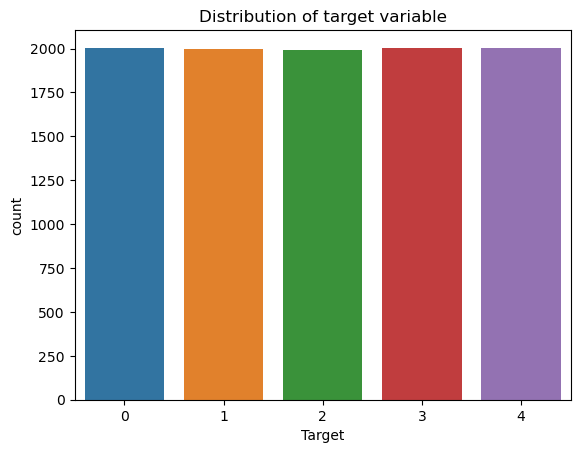

In [12]:
# checking for null values
print(df.isnull().sum())
# checking for duplicates
print(df.duplicated().sum())
# checking the distribution of the target variable
print(df['Target'].value_counts())
# checking the distribution of the target variable
sns.countplot(x='Target', data=df)
plt.title('Distribution of target variable')
plt.show()

- there are no missing values.
- there is no duplicates.
- target feature is not imbalance.

#### Data Preprocessing

In [14]:
# lets check the correlation between the features
corr = df.corr()
corr

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Target
Feature_1,1.000000,0.359137,0.374757,0.132231,-0.311347,0.213934,-0.353584,0.452104,-0.046364,-0.175393,...,-0.329601,0.538802,0.151391,-0.124965,-0.369233,-0.086957,-0.065851,-0.355150,0.090639,-0.090732
Feature_2,0.359137,1.000000,0.202851,-0.204180,0.131771,0.266292,-0.141838,0.316019,-0.406798,-0.103727,...,-0.172121,0.478257,-0.106632,0.305601,-0.452343,0.167863,0.025780,-0.009452,-0.359906,0.027886
Feature_3,0.374757,0.202851,1.000000,-0.076411,-0.149003,0.087443,0.036009,0.087490,0.023363,0.344737,...,-0.126463,0.029096,-0.053237,0.054965,-0.011118,-0.052786,0.154004,-0.282652,-0.018527,-0.120003
Feature_4,0.132231,-0.204180,-0.076411,1.000000,0.119901,-0.058980,-0.349660,-0.157968,0.262124,-0.307147,...,-0.085315,0.068418,-0.059367,0.079143,0.036087,0.000019,0.014716,-0.184426,0.080147,-0.059484
Feature_5,-0.311347,0.131771,-0.149003,0.119901,1.000000,-0.114270,-0.523135,-0.081205,0.110378,0.180646,...,0.027277,-0.051312,-0.067339,-0.061889,-0.045921,-0.052479,0.182200,0.319979,0.173765,-0.050310
Feature_6,0.213934,0.266292,0.087443,-0.058980,-0.114270,1.000000,0.011054,0.040769,-0.054183,-0.288093,...,-0.076746,0.084398,-0.111879,0.007228,0.125700,0.131275,0.035890,0.150637,-0.106099,-0.137381
Feature_7,-0.353584,-0.141838,0.036009,-0.349660,-0.523135,0.011054,1.000000,-0.307981,-0.198455,0.031965,...,0.158533,-0.184638,0.184054,0.123666,0.383842,0.319110,-0.467510,0.110746,-0.151950,0.076784
Feature_8,0.452104,0.316019,0.087490,-0.157968,-0.081205,0.040769,-0.307981,1.000000,-0.104277,-0.013432,...,-0.088594,0.112939,-0.076033,0.020260,-0.173507,0.132563,0.098835,-0.189065,-0.048695,0.008150
Feature_9,-0.046364,-0.406798,0.023363,0.262124,0.110378,-0.054183,-0.198455,-0.104277,1.000000,0.225338,...,-0.041718,0.000297,0.095353,-0.131705,-0.093007,-0.020112,0.060977,-0.313998,0.063934,0.046365
Feature_10,-0.175393,-0.103727,0.344737,-0.307147,0.180646,-0.288093,0.031965,-0.013432,0.225338,1.000000,...,0.011113,-0.377818,0.331202,-0.221186,-0.033856,0.196194,0.058424,-0.202968,-0.318282,-0.002839


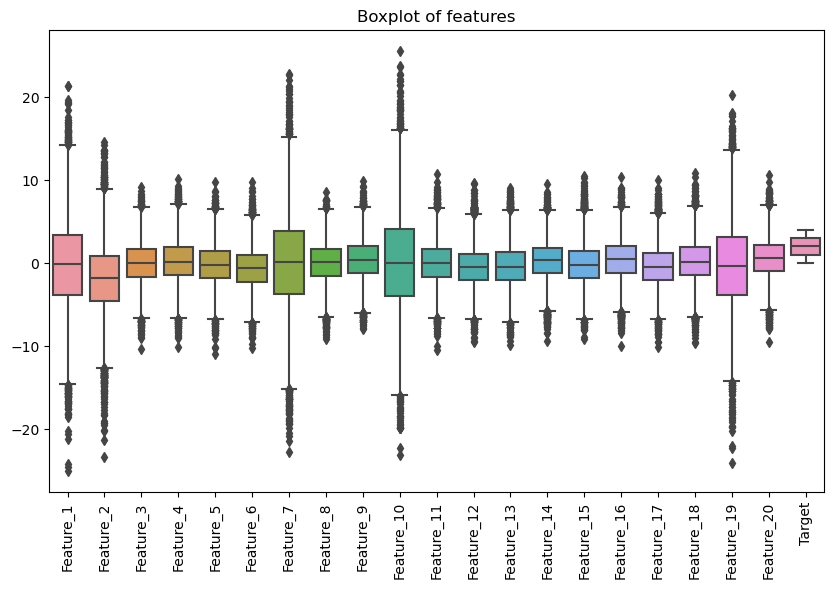

In [17]:
# checking outliers in data
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot of features')
plt.xticks(rotation=90)
plt.show()

- there are few outlier.
- assuming all datapoint is real.

In [18]:
# # lets check data distribution
# sns.pairplot(df, hue='Target')

In [43]:
# copying the data
df1 = df.copy()

In [44]:
# lets scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df1.iloc[:, :-1] = scaler.fit_transform(df1.iloc[:, :-1])

In [45]:
# lets separate the features and target variable
X = df1.drop('Target', axis=1)
y = df1['Target']

In [46]:
# lets split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Model Building

In [47]:
input_dim = 20  

# Build the model
model = Sequential()
model.add(Dense(200, input_dim=input_dim, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.6))
model.add(Dense(50, activation='relu')) 
model.add(Dropout(0.6))
model.add(Dense(25, activation='relu'))
model.add(Dropout(0.6))
# Output layer
# for multiclass classification    
model.add(Dense(5, activation='softmax'))

In [48]:
# compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [49]:
# checking the model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 200)            │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,755 (120.14 KB)

 Trainable params: 30,755 (120.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.2213 - loss: 1.6476 - val_accuracy: 0.4750 - val_loss: 1.4917
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3152 - loss: 1.4949 - val_accuracy: 0.6200 - val_loss: 1.2687
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4229 - loss: 1.3344 - val_accuracy: 0.6950 - val_loss: 1.0588
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5196 - loss: 1.2116 - val_accuracy: 0.7437 - val_loss: 0.9203
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5925 - loss: 1.0970 - val_accuracy: 0.7800 - val_loss: 0.8044
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6360 - loss: 1.0126 - val_accuracy: 0.8106 - val_loss: 0.6940
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6802 - loss: 0.9194 - val_accuracy: 0.8263 - val_loss: 0.6151
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7083 - loss: 0.8627 - val_a

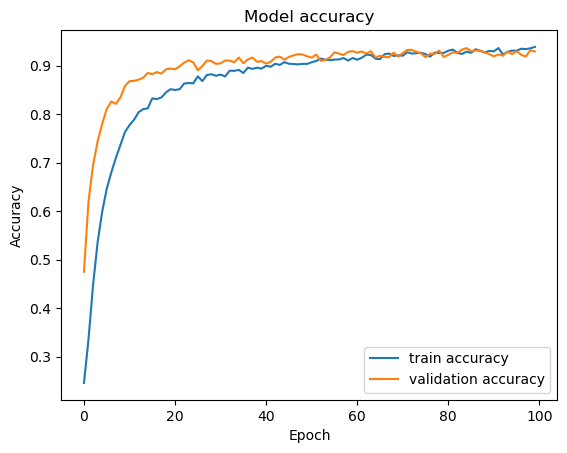

In [50]:
# fit the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)
# plot the training history
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

- mode is performing well and getting around 92%

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


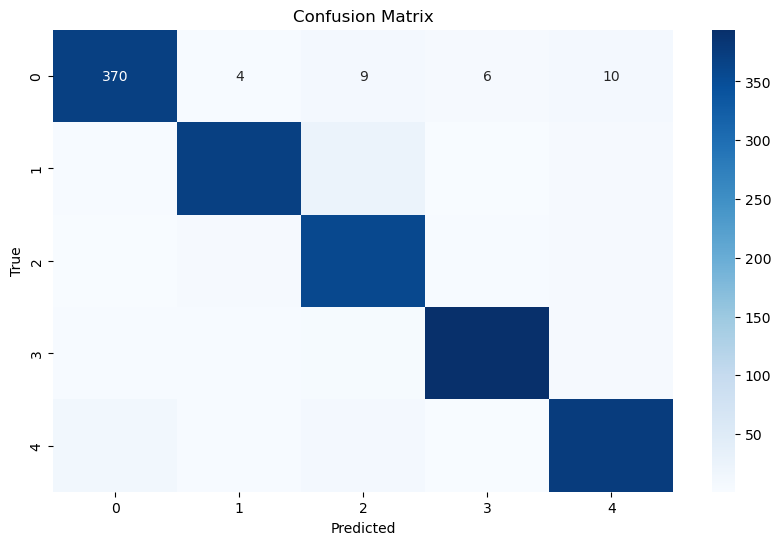

array([[370,   4,   9,   6,  10],
       [  4, 370,  25,   2,   6],
       [  2,   7, 358,   4,   7],
       [  4,   4,   5, 394,   7],
       [ 14,   3,   9,   1, 375]])

In [52]:
# lets check evaluation metrics for multiclass classification
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
# confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
cm

In [53]:
# lets check classification report
print(classification_report(y_test, y_pred_classes))
# lets check accuracy score
accuracy = accuracy_score(y_test, y_pred_classes)
print('Accuracy:', accuracy)
# lets check precision score
precision = precision_score(y_test, y_pred_classes, average='weighted')
print('Precision:', precision)
# lets check recall score
recall = recall_score(y_test, y_pred_classes, average='weighted')
print('Recall:', recall)
# lets check f1 score           
f1 = f1_score(y_test, y_pred_classes, average='weighted')
print('F1 Score:', f1)

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       399
           1       0.95      0.91      0.93       407
           2       0.88      0.95      0.91       378
           3       0.97      0.95      0.96       414
           4       0.93      0.93      0.93       402

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000

Accuracy: 0.9335
Precision: 0.9345614839996668
Recall: 0.9335
F1 Score: 0.9336776159294591


#### Conclusion

- model is performing well in train and test set.
- accuracy is around 93%
- precision is around 93%
- recall is around 93%
- f1 is around 93%
- so this is generalized model.